<a href="https://colab.research.google.com/github/Subuktageen-Farooqi/ms_course_deeplearning/blob/main/ms_deeplearning_tutorial_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1 : Import Necessary Libraries

In [ ]:
import numpy
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

Step 2 : Load & pre-process MNIST dataset

In [ ]:
(train_images, train_labels), (test_images, test_lablels) = mnist.load_data()

train_images = train_images.astype('float32') / 255.0
test_images = test_images.astype('float32') / 255.0

train_labels = to_categorical(train_labels, num_classes=10)
test_labels = to_categorical(test_lablels, num_classes=10)

In [ ]:
size = train_images[0].shape

Step 3 : Building the Neural Network Model

In [ ]:
model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax'),
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Step 4 : Compiling the Model

In [ ]:
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

Step 5 : Training the Model

In [ ]:
history = model.fit(train_images, train_labels, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9216 - loss: 0.2693 - val_accuracy: 0.9590 - val_loss: 0.1381
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9661 - loss: 0.1090 - val_accuracy: 0.9653 - val_loss: 0.1115
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9768 - loss: 0.0755 - val_accuracy: 0.9678 - val_loss: 0.1044
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9814 - loss: 0.0570 - val_accuracy: 0.9726 - val_loss: 0.0938
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9853 - loss: 0.0446 - val_accuracy: 0.9746 - val_loss: 0.0876
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9880 - loss: 0.0360 - val_accuracy: 0.9731 - val_loss: 0.0992
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9903 - loss: 0.0289 - val_accuracy: 0.9763 - val_loss: 0.0942
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9915 - loss: 0.0256 - 

Step 6 : Evaluating the Model

In [ ]:
test_loss, test_accuracy = model.evaluate(x=test_images, y=test_labels)
print(f"Test accuracy: {test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9737 - loss: 0.1018
Test accuracy: 0.9737


Step 7 : Visualizing Training and Validation Performance

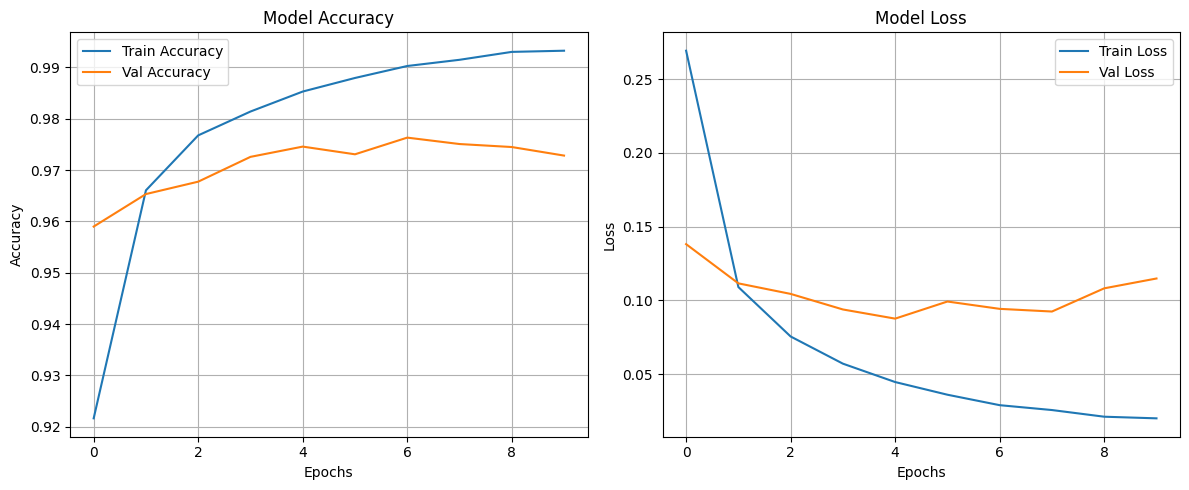

In [ ]:
plt.figure(figsize=(12, 5))  # Create a figure with a specific size

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)  # Create a subplot for accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')  # Plot training accuracy
plt.plot(history.history['val_accuracy'], label='Val Accuracy')  # Plot validation accuracy
plt.title('Model Accuracy')  # Set the title
plt.xlabel('Epochs')  # Set x-axis label
plt.ylabel('Accuracy')  # Set y-axis label
plt.legend()  # Show legend
plt.grid()  # Add grid lines

# Plot training & validation loss values
plt.subplot(1, 2, 2)  # Create a subplot for loss
plt.plot(history.history['loss'], label='Train Loss')  # Plot training loss
plt.plot(history.history['val_loss'], label='Val Loss')  # Plot validation loss
plt.title('Model Loss')  # Set the title
plt.xlabel('Epochs')  # Set x-axis label
plt.ylabel('Loss')  # Set y-axis label
plt.legend()  # Show legend
plt.grid()  # Add grid lines

plt.tight_layout()  # Adjust subplots to fit into figure area.
plt.show()  # Display the plots

Step 8 : Making Predictions and Visualizing Results


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


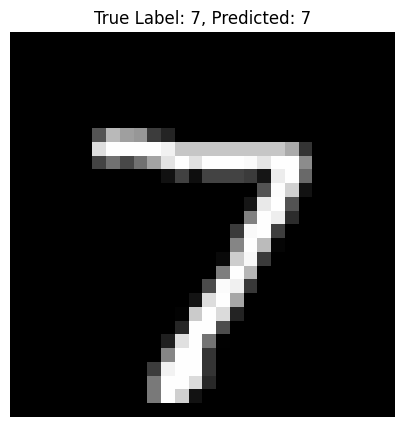

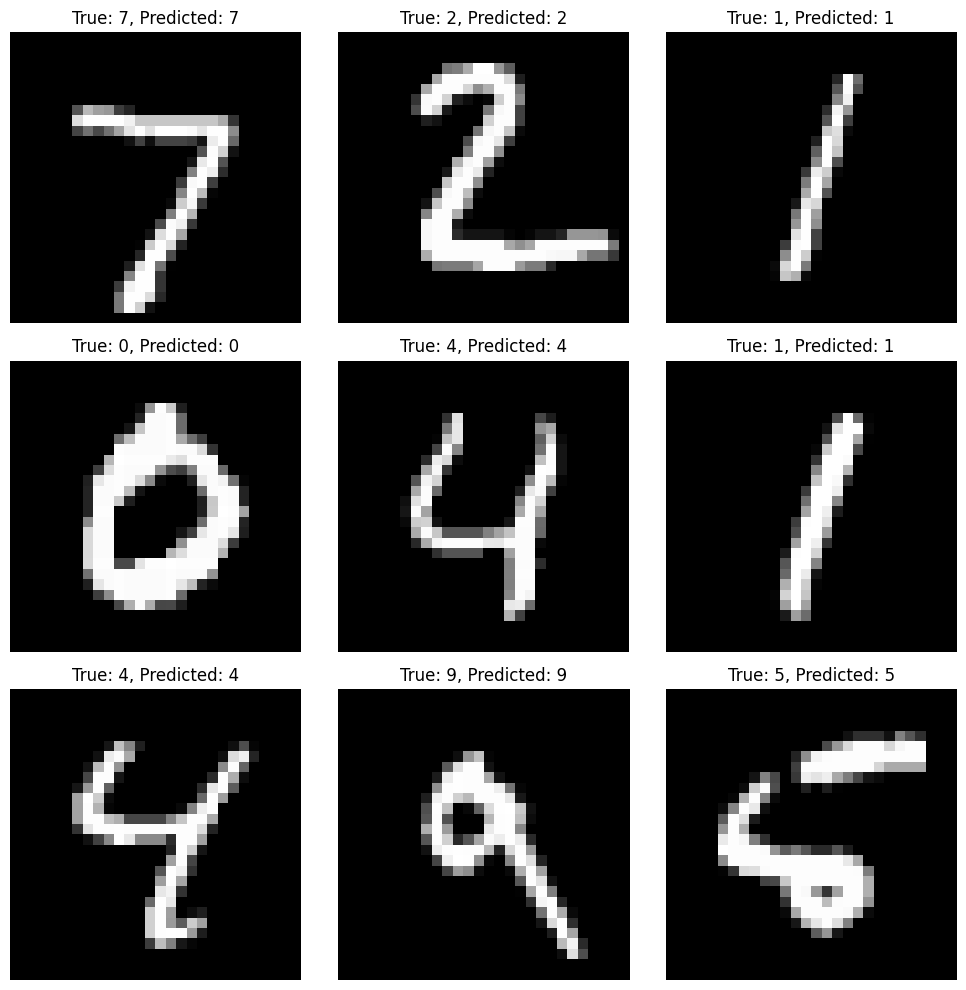

In [ ]:
predictions = model.predict(test_images)

# Display the first test image and its predicted label
plt.figure(figsize=(5, 5))  # Create a figure for the image
plt.imshow(test_images[0], cmap='gray')  # Show the first test image in grayscale
plt.title(f"True Label: {numpy.argmax(test_labels[0])}, Predicted: {numpy.argmax(predictions[0])}")  # Display true and predicted labels
plt.axis('off')  # Hide the axis
plt.show()  # Display the image

# Display a grid of images with true and predicted labels
num_images = 9  # Number of images to display
plt.figure(figsize=(10, 10))  # Create a figure for the grid of images
for i in range(num_images):
    plt.subplot(3, 3, i + 1)  # Create a 3x3 grid of subplots
    plt.imshow(test_images[i], cmap='gray')  # Show each test image in grayscale
    plt.title(f"True: {numpy.argmax(test_labels[i])}, Predicted: {numpy.argmax(predictions[i])}")  # Display true and predicted labels
    plt.axis('off')  # Hide the axis
plt.tight_layout()  # Adjust subplots to fit into figure area.
plt.show()  # Display the grid of images

# Tasks_

Task_01: Implementation with PyTorch

In [ ]:
import time
import copy
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

# ----------------------------
# Device
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ----------------------------
# Hyperparameters
# ----------------------------
batch_size = 64
learning_rate = 0.001
num_epochs = 20
# patience = 5  # early stopping patience

# ----------------------------
# Dataset: MNIST
# ----------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

full_train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# ----------------------------
# Model
# ----------------------------
class SimpleMLP(nn.Module):
    def __init__(self, input_size=28*28, hidden1=128, hidden2=64, num_classes=10, activation="relu", dropout=0.0):
        super().__init__()

        if activation == "relu":
            act = nn.ReLU()
        elif activation == "tanh":
            act = nn.Tanh()
        elif activation == "sigmoid":
            act = nn.Sigmoid()
        else:
            raise ValueError("Unsupported activation")

        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_size, hidden1),
            act,
            nn.Dropout(dropout),

            nn.Linear(hidden1, hidden2),
            act,
            nn.Dropout(dropout),

            nn.Linear(hidden2, num_classes)
        )

    def forward(self, x):
        return self.net(x)

# ----------------------------
# Training / Evaluation Helpers
# ----------------------------
def calculate_accuracy(outputs, labels):
    _, preds = torch.max(outputs, 1)
    correct = (preds == labels).sum().item()
    return correct / labels.size(0)

def evaluate_model(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    running_acc = 0.0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            batch_size_local = labels.size(0)
            running_loss += loss.item() * batch_size_local
            running_acc += calculate_accuracy(outputs, labels) * batch_size_local
            total += batch_size_local

    return running_loss / total, running_acc / total

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=20, patience=5):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_loss = float("inf")
    # patience_counter = 0

    start_time = time.time()

    for epoch in range(num_epochs):
        model.train()

        running_loss = 0.0
        running_acc = 0.0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            batch_size_local = labels.size(0)
            running_loss += loss.item() * batch_size_local
            running_acc += calculate_accuracy(outputs, labels) * batch_size_local
            total += batch_size_local

        train_loss = running_loss / total
        train_acc = running_acc / total

        val_loss, val_acc = evaluate_model(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch [{epoch+1}/{num_epochs}] | "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
        )

        # # Early Stopping
        # if val_loss < best_val_loss:
        #     best_val_loss = val_loss
        #     best_model_wts = copy.deepcopy(model.state_dict())
        #     patience_counter = 0
        # else:
        #     patience_counter += 1
        #     if patience_counter >= patience:
        #         print("Early stopping triggered.")
        #         break

    total_time = time.time() - start_time
    #model.load_state_dict(best_model_wts)

    return model, history, total_time

def plot_history(history, title_suffix=""):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history["train_acc"], label="Train Accuracy")
    plt.plot(history["val_acc"], label="Val Accuracy")
    plt.title(f"Model Accuracy {title_suffix}")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.title(f"Model Loss {title_suffix}")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()

def test_model(model, test_loader, criterion):
    test_loss, test_acc = evaluate_model(model, test_loader, criterion)
    print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")
    return test_loss, test_acc

def show_predictions(model, test_loader, class_names=None, num_images=9):
    model.eval()
    images, labels = next(iter(test_loader))
    images, labels = images.to(device), labels.to(device)

    with torch.no_grad():
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

    images = images.cpu()
    labels = labels.cpu()
    preds = preds.cpu()

    plt.figure(figsize=(10, 10))
    for i in range(num_images):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].squeeze(), cmap="gray")
        true_label = labels[i].item()
        pred_label = preds[i].item()

        if class_names:
            plt.title(f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}")
        else:
            plt.title(f"True: {true_label}, Pred: {pred_label}")

        plt.axis("off")

    plt.tight_layout()
    plt.show()

Using device: cuda


Epoch [1/20] | Train Loss: 0.4371, Train Acc: 0.8709 | Val Loss: 0.2838, Val Acc: 0.9129
Epoch [2/20] | Train Loss: 0.2128, Train Acc: 0.9364 | Val Loss: 0.2182, Val Acc: 0.9307
Epoch [3/20] | Train Loss: 0.1531, Train Acc: 0.9536 | Val Loss: 0.1599, Val Acc: 0.9526
Epoch [4/20] | Train Loss: 0.1224, Train Acc: 0.9630 | Val Loss: 0.1332, Val Acc: 0.9597
Epoch [5/20] | Train Loss: 0.1077, Train Acc: 0.9667 | Val Loss: 0.1293, Val Acc: 0.9609
Epoch [6/20] | Train Loss: 0.0920, Train Acc: 0.9716 | Val Loss: 0.1566, Val Acc: 0.9533
Epoch [7/20] | Train Loss: 0.0812, Train Acc: 0.9744 | Val Loss: 0.1145, Val Acc: 0.9657
Epoch [8/20] | Train Loss: 0.0724, Train Acc: 0.9768 | Val Loss: 0.1016, Val Acc: 0.9689
Epoch [9/20] | Train Loss: 0.0659, Train Acc: 0.9784 | Val Loss: 0.1151, Val Acc: 0.9667
Epoch [10/20] | Train Loss: 0.0594, Train Acc: 0.9802 | Val Loss: 0.1063, Val Acc: 0.9690
Epoch [11/20] | Train Loss: 0.0543, Train Acc: 0.9826 | Val Loss: 0.1177, Val Acc: 0.9663
Epoch [12/20] | Tra

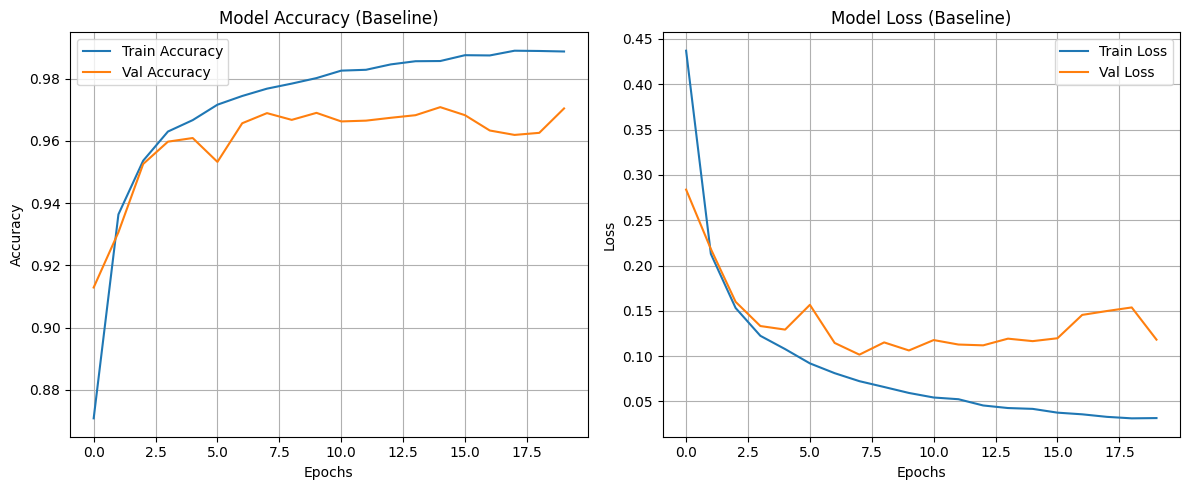

Test Loss: 0.1046, Test Accuracy: 0.9746


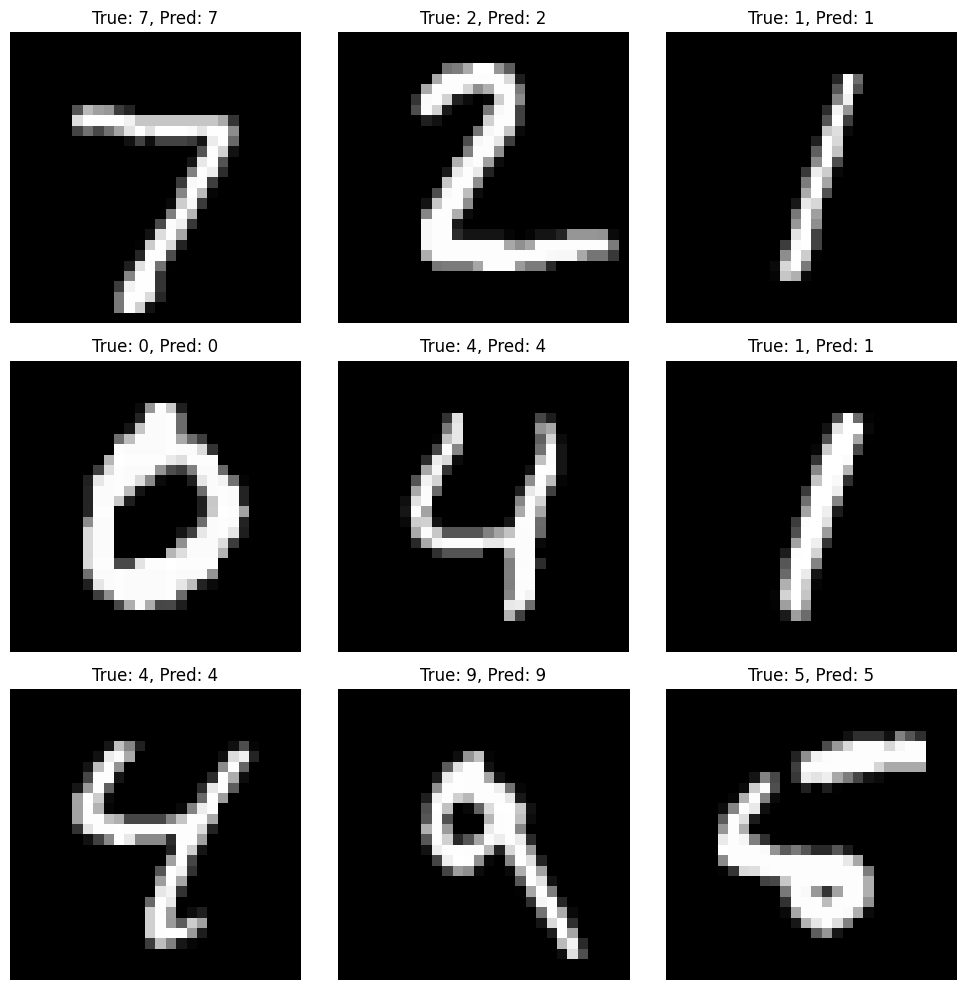

In [ ]:
 # baseline model run
criterion = nn.CrossEntropyLoss()

baseline_model = SimpleMLP(
    hidden1=128,
    hidden2=64,
    activation="relu",
    dropout=0.0
).to(device)

baseline_optimizer = optim.Adam(baseline_model.parameters(), lr=learning_rate)

baseline_model, baseline_history, baseline_time = train_model(
    baseline_model,
    train_loader,
    val_loader,
    criterion,
    baseline_optimizer,
    num_epochs=num_epochs,
    # patience=patience
)

plot_history(baseline_history, "(Baseline)")
baseline_test_loss, baseline_test_acc = test_model(baseline_model, test_loader, criterion)
show_predictions(baseline_model, test_loader)

Task_02: Experiment with Architectures


*   add more layers
*   change neurons
*   change activation functions










Running architecture experiment: Original_ReLU
Epoch [1/20] | Train Loss: 0.4170, Train Acc: 0.8778 | Val Loss: 0.2597, Val Acc: 0.9211
Epoch [2/20] | Train Loss: 0.2115, Train Acc: 0.9362 | Val Loss: 0.2128, Val Acc: 0.9335
Epoch [3/20] | Train Loss: 0.1526, Train Acc: 0.9540 | Val Loss: 0.1543, Val Acc: 0.9520
Epoch [4/20] | Train Loss: 0.1210, Train Acc: 0.9633 | Val Loss: 0.1320, Val Acc: 0.9583
Epoch [5/20] | Train Loss: 0.1017, Train Acc: 0.9688 | Val Loss: 0.1123, Val Acc: 0.9638
Epoch [6/20] | Train Loss: 0.0888, Train Acc: 0.9725 | Val Loss: 0.1052, Val Acc: 0.9671
Epoch [7/20] | Train Loss: 0.0776, Train Acc: 0.9756 | Val Loss: 0.1061, Val Acc: 0.9668
Epoch [8/20] | Train Loss: 0.0670, Train Acc: 0.9777 | Val Loss: 0.1060, Val Acc: 0.9673
Epoch [9/20] | Train Loss: 0.0609, Train Acc: 0.9806 | Val Loss: 0.0952, Val Acc: 0.9695
Epoch [10/20] | Train Loss: 0.0560, Train Acc: 0.9820 | Val Loss: 0.0981, Val Acc: 0.9720
Epoch [11/20] | Train Loss: 0.0506, Train Acc: 0.9834 | Val L

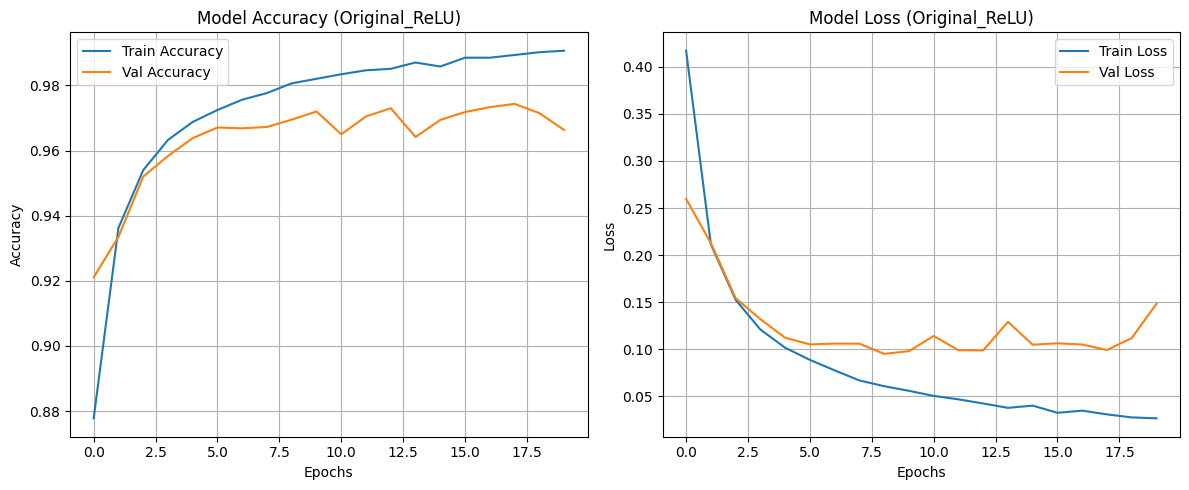


Running architecture experiment: More_Neurons_ReLU
Epoch [1/20] | Train Loss: 0.3741, Train Acc: 0.8849 | Val Loss: 0.2321, Val Acc: 0.9274
Epoch [2/20] | Train Loss: 0.1684, Train Acc: 0.9478 | Val Loss: 0.1628, Val Acc: 0.9500
Epoch [3/20] | Train Loss: 0.1224, Train Acc: 0.9624 | Val Loss: 0.1377, Val Acc: 0.9583
Epoch [4/20] | Train Loss: 0.0995, Train Acc: 0.9683 | Val Loss: 0.1125, Val Acc: 0.9658
Epoch [5/20] | Train Loss: 0.0820, Train Acc: 0.9743 | Val Loss: 0.1157, Val Acc: 0.9650
Epoch [6/20] | Train Loss: 0.0694, Train Acc: 0.9775 | Val Loss: 0.0960, Val Acc: 0.9714
Epoch [7/20] | Train Loss: 0.0623, Train Acc: 0.9800 | Val Loss: 0.1203, Val Acc: 0.9643
Epoch [8/20] | Train Loss: 0.0555, Train Acc: 0.9814 | Val Loss: 0.1066, Val Acc: 0.9691
Epoch [9/20] | Train Loss: 0.0490, Train Acc: 0.9837 | Val Loss: 0.1211, Val Acc: 0.9653
Epoch [10/20] | Train Loss: 0.0466, Train Acc: 0.9845 | Val Loss: 0.1116, Val Acc: 0.9678
Epoch [11/20] | Train Loss: 0.0377, Train Acc: 0.9877 | V

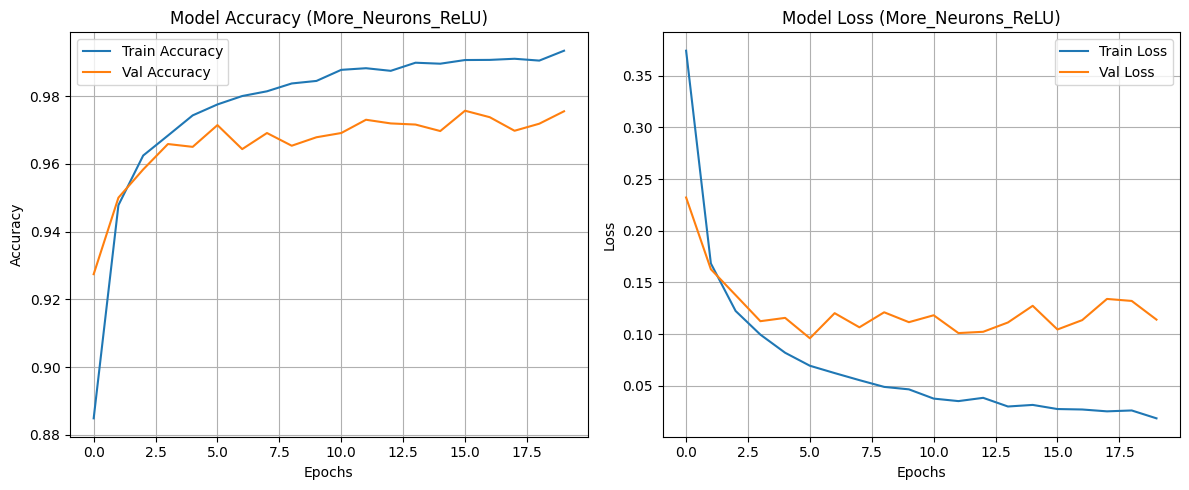


Running architecture experiment: Deep_ReLU
Epoch [1/20] | Train Loss: 0.5254, Train Acc: 0.8344 | Val Loss: 0.2486, Val Acc: 0.9229
Epoch [2/20] | Train Loss: 0.2508, Train Acc: 0.9263 | Val Loss: 0.1724, Val Acc: 0.9477
Epoch [3/20] | Train Loss: 0.2017, Train Acc: 0.9407 | Val Loss: 0.1509, Val Acc: 0.9537
Epoch [4/20] | Train Loss: 0.1755, Train Acc: 0.9478 | Val Loss: 0.1608, Val Acc: 0.9507
Epoch [5/20] | Train Loss: 0.1574, Train Acc: 0.9534 | Val Loss: 0.1221, Val Acc: 0.9653
Epoch [6/20] | Train Loss: 0.1440, Train Acc: 0.9560 | Val Loss: 0.1198, Val Acc: 0.9639
Epoch [7/20] | Train Loss: 0.1313, Train Acc: 0.9610 | Val Loss: 0.1107, Val Acc: 0.9673
Epoch [8/20] | Train Loss: 0.1222, Train Acc: 0.9626 | Val Loss: 0.1044, Val Acc: 0.9717
Epoch [9/20] | Train Loss: 0.1191, Train Acc: 0.9649 | Val Loss: 0.1210, Val Acc: 0.9655
Epoch [10/20] | Train Loss: 0.1160, Train Acc: 0.9652 | Val Loss: 0.1020, Val Acc: 0.9698
Epoch [11/20] | Train Loss: 0.1070, Train Acc: 0.9682 | Val Loss:

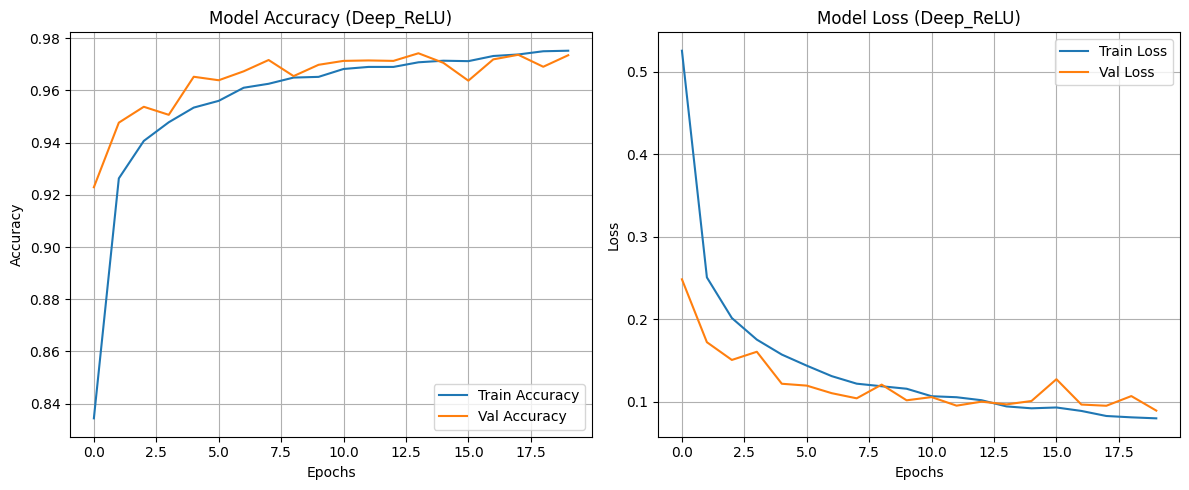


Running architecture experiment: Deep_Tanh
Epoch [1/20] | Train Loss: 0.4486, Train Acc: 0.8709 | Val Loss: 0.2579, Val Acc: 0.9242
Epoch [2/20] | Train Loss: 0.2503, Train Acc: 0.9263 | Val Loss: 0.2137, Val Acc: 0.9340
Epoch [3/20] | Train Loss: 0.2196, Train Acc: 0.9348 | Val Loss: 0.1743, Val Acc: 0.9458
Epoch [4/20] | Train Loss: 0.1987, Train Acc: 0.9410 | Val Loss: 0.1621, Val Acc: 0.9507
Epoch [5/20] | Train Loss: 0.1899, Train Acc: 0.9428 | Val Loss: 0.1745, Val Acc: 0.9484
Epoch [6/20] | Train Loss: 0.1788, Train Acc: 0.9453 | Val Loss: 0.1567, Val Acc: 0.9524
Epoch [7/20] | Train Loss: 0.1693, Train Acc: 0.9494 | Val Loss: 0.1456, Val Acc: 0.9566
Epoch [8/20] | Train Loss: 0.1687, Train Acc: 0.9490 | Val Loss: 0.1590, Val Acc: 0.9547
Epoch [9/20] | Train Loss: 0.1637, Train Acc: 0.9514 | Val Loss: 0.1437, Val Acc: 0.9583
Epoch [10/20] | Train Loss: 0.1606, Train Acc: 0.9514 | Val Loss: 0.1386, Val Acc: 0.9597
Epoch [11/20] | Train Loss: 0.1561, Train Acc: 0.9536 | Val Loss:

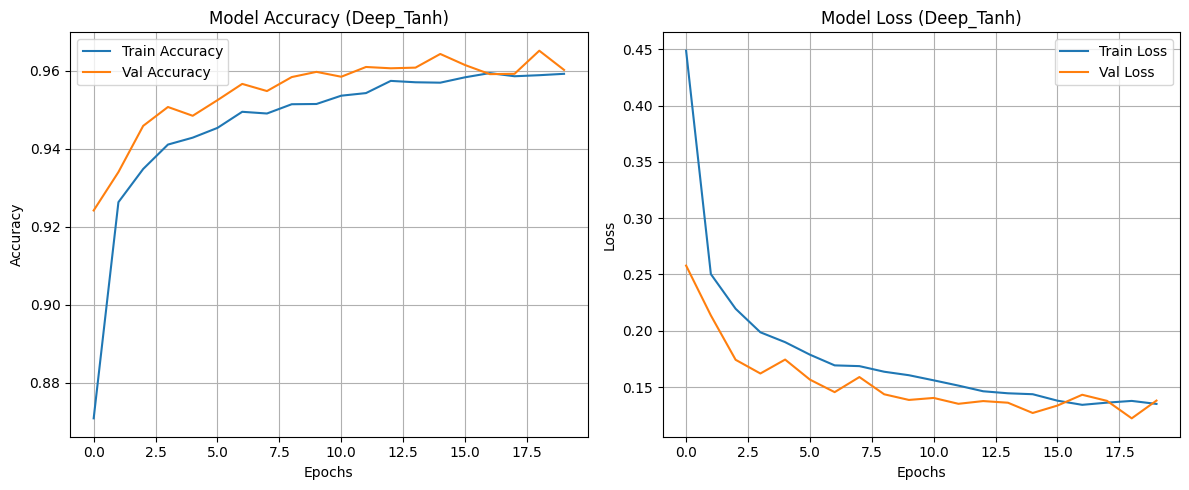


Running architecture experiment: Deep_Sigmoid
Epoch [1/20] | Train Loss: 0.9599, Train Acc: 0.7020 | Val Loss: 0.3807, Val Acc: 0.8973
Epoch [2/20] | Train Loss: 0.3223, Train Acc: 0.9148 | Val Loss: 0.2377, Val Acc: 0.9310
Epoch [3/20] | Train Loss: 0.2376, Train Acc: 0.9346 | Val Loss: 0.1877, Val Acc: 0.9454
Epoch [4/20] | Train Loss: 0.1914, Train Acc: 0.9481 | Val Loss: 0.1591, Val Acc: 0.9541
Epoch [5/20] | Train Loss: 0.1659, Train Acc: 0.9544 | Val Loss: 0.1408, Val Acc: 0.9599
Epoch [6/20] | Train Loss: 0.1465, Train Acc: 0.9572 | Val Loss: 0.1489, Val Acc: 0.9543
Epoch [7/20] | Train Loss: 0.1386, Train Acc: 0.9600 | Val Loss: 0.1326, Val Acc: 0.9616
Epoch [8/20] | Train Loss: 0.1260, Train Acc: 0.9635 | Val Loss: 0.1196, Val Acc: 0.9646
Epoch [9/20] | Train Loss: 0.1159, Train Acc: 0.9669 | Val Loss: 0.1177, Val Acc: 0.9659
Epoch [10/20] | Train Loss: 0.1137, Train Acc: 0.9670 | Val Loss: 0.1129, Val Acc: 0.9661
Epoch [11/20] | Train Loss: 0.1046, Train Acc: 0.9692 | Val Lo

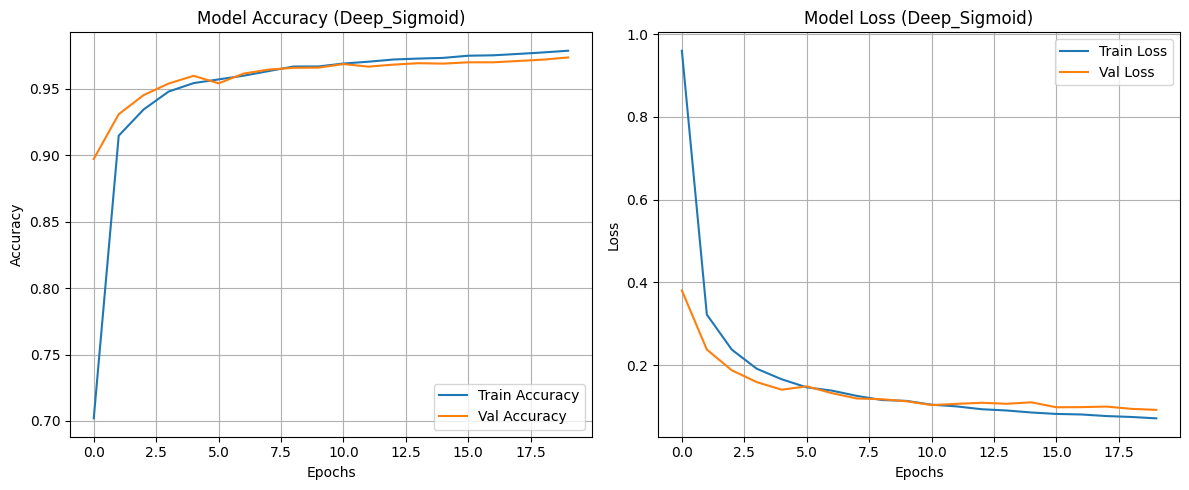


Architecture Comparison
Original_ReLU        | Train Acc: 0.9907 | Val Acc: 0.9663 | Test Acc: 0.9681 | Loss: 0.1307 | Epochs: 20 | Time: 280.94s
More_Neurons_ReLU    | Train Acc: 0.9934 | Val Acc: 0.9755 | Test Acc: 0.9751 | Loss: 0.1032 | Epochs: 20 | Time: 281.20s
Deep_ReLU            | Train Acc: 0.9752 | Val Acc: 0.9735 | Test Acc: 0.9735 | Loss: 0.0892 | Epochs: 20 | Time: 286.43s
Deep_Tanh            | Train Acc: 0.9592 | Val Acc: 0.9602 | Test Acc: 0.9659 | Loss: 0.1184 | Epochs: 20 | Time: 284.63s
Deep_Sigmoid         | Train Acc: 0.9788 | Val Acc: 0.9738 | Test Acc: 0.9761 | Loss: 0.0809 | Epochs: 20 | Time: 285.17s


In [ ]:
# Architecture A: Deeper Network
class DeepMLP(nn.Module):
    def __init__(self, input_size=28*28, num_classes=10, activation="relu", dropout=0.2):
        super().__init__()

        if activation == "relu":
            act = nn.ReLU()
        elif activation == "tanh":
            act = nn.Tanh()
        elif activation == "sigmoid":
            act = nn.Sigmoid()
        else:
            raise ValueError("Unsupported activation")

        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_size, 256),
            act,
            nn.Dropout(dropout),

            nn.Linear(256, 128),
            act,
            nn.Dropout(dropout),

            nn.Linear(128, 64),
            act,
            nn.Dropout(dropout),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.net(x)

# Run experiments
architecture_results = []

configs = [
    {"name": "Original_ReLU", "model_type": "simple", "hidden1": 128, "hidden2": 64, "activation": "relu", "dropout": 0.0},
    {"name": "More_Neurons_ReLU", "model_type": "simple", "hidden1": 256, "hidden2": 128, "activation": "relu", "dropout": 0.0},
    {"name": "Deep_ReLU", "model_type": "deep", "activation": "relu", "dropout": 0.2},
    {"name": "Deep_Tanh", "model_type": "deep", "activation": "tanh", "dropout": 0.2},
    {"name": "Deep_Sigmoid", "model_type": "deep", "activation": "sigmoid", "dropout": 0.2},
]

for cfg in configs:
    print(f"\nRunning architecture experiment: {cfg['name']}")

    if cfg["model_type"] == "simple":
        model = SimpleMLP(
            hidden1=cfg["hidden1"],
            hidden2=cfg["hidden2"],
            activation=cfg["activation"],
            dropout=cfg["dropout"]
        ).to(device)
    else:
        model = DeepMLP(
            activation=cfg["activation"],
            dropout=cfg["dropout"]
        ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    model, history, train_time = train_model(
        model, train_loader, val_loader, criterion, optimizer,
        num_epochs=num_epochs, ###patience=patience###
    )

    test_loss, test_acc = test_model(model, test_loader, criterion)

    architecture_results.append({
        "name": cfg["name"],
        "final_train_acc": history["train_acc"][-1],
        "final_val_acc": history["val_acc"][-1],
        "test_acc": test_acc,
        "test_loss": test_loss,
        "epochs_run": len(history["train_acc"]),
        "train_time_sec": train_time
    })

    plot_history(history, f"({cfg['name']})")


print("\nArchitecture Comparison")
for r in architecture_results:
    print(
        f"{r['name']:20s} | "
        f"Train Acc: {r['final_train_acc']:.4f} | "
        f"Val Acc: {r['final_val_acc']:.4f} | "
        f"Test Acc: {r['test_acc']:.4f} | "
        f"Loss: {r['test_loss']:.4f} | "
        f"Epochs: {r['epochs_run']} | "
        f"Time: {r['train_time_sec']:.2f}s"
    )

Task_03: Compare Different Optimizers


Running optimizer experiment: SGD
Epoch [1/20] | Train Loss: 0.4751, Train Acc: 0.8582 | Val Loss: 0.2743, Val Acc: 0.9156
Epoch [2/20] | Train Loss: 0.1973, Train Acc: 0.9401 | Val Loss: 0.1812, Val Acc: 0.9464
Epoch [3/20] | Train Loss: 0.1391, Train Acc: 0.9575 | Val Loss: 0.1528, Val Acc: 0.9558
Epoch [4/20] | Train Loss: 0.1149, Train Acc: 0.9644 | Val Loss: 0.1344, Val Acc: 0.9590
Epoch [5/20] | Train Loss: 0.0928, Train Acc: 0.9717 | Val Loss: 0.1321, Val Acc: 0.9602
Epoch [6/20] | Train Loss: 0.0813, Train Acc: 0.9746 | Val Loss: 0.1115, Val Acc: 0.9666
Epoch [7/20] | Train Loss: 0.0711, Train Acc: 0.9776 | Val Loss: 0.1089, Val Acc: 0.9688
Epoch [8/20] | Train Loss: 0.0626, Train Acc: 0.9797 | Val Loss: 0.0988, Val Acc: 0.9698
Epoch [9/20] | Train Loss: 0.0568, Train Acc: 0.9812 | Val Loss: 0.0971, Val Acc: 0.9721
Epoch [10/20] | Train Loss: 0.0487, Train Acc: 0.9841 | Val Loss: 0.1094, Val Acc: 0.9676
Epoch [11/20] | Train Loss: 0.0459, Train Acc: 0.9848 | Val Loss: 0.0929, 

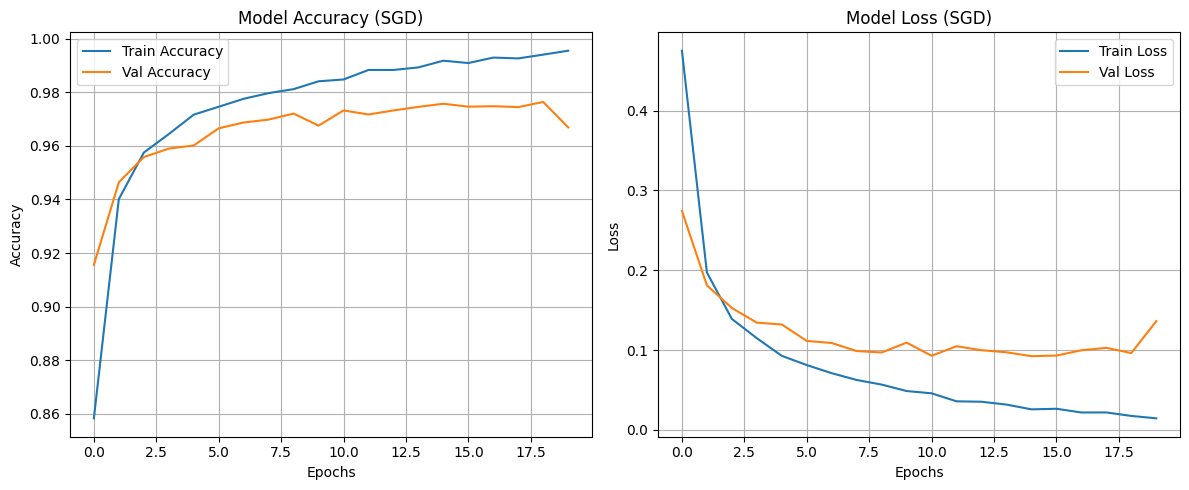


Running optimizer experiment: RMSprop
Epoch [1/20] | Train Loss: 0.4166, Train Acc: 0.8711 | Val Loss: 0.2390, Val Acc: 0.9258
Epoch [2/20] | Train Loss: 0.2074, Train Acc: 0.9361 | Val Loss: 0.2103, Val Acc: 0.9343
Epoch [3/20] | Train Loss: 0.1549, Train Acc: 0.9520 | Val Loss: 0.1575, Val Acc: 0.9491
Epoch [4/20] | Train Loss: 0.1256, Train Acc: 0.9615 | Val Loss: 0.1396, Val Acc: 0.9577
Epoch [5/20] | Train Loss: 0.1069, Train Acc: 0.9670 | Val Loss: 0.1338, Val Acc: 0.9586
Epoch [6/20] | Train Loss: 0.0947, Train Acc: 0.9695 | Val Loss: 0.1423, Val Acc: 0.9550
Epoch [7/20] | Train Loss: 0.0840, Train Acc: 0.9741 | Val Loss: 0.1507, Val Acc: 0.9571
Epoch [8/20] | Train Loss: 0.0766, Train Acc: 0.9750 | Val Loss: 0.1202, Val Acc: 0.9637
Epoch [9/20] | Train Loss: 0.0689, Train Acc: 0.9789 | Val Loss: 0.1516, Val Acc: 0.9571
Epoch [10/20] | Train Loss: 0.0635, Train Acc: 0.9788 | Val Loss: 0.1145, Val Acc: 0.9663
Epoch [11/20] | Train Loss: 0.0576, Train Acc: 0.9816 | Val Loss: 0.10

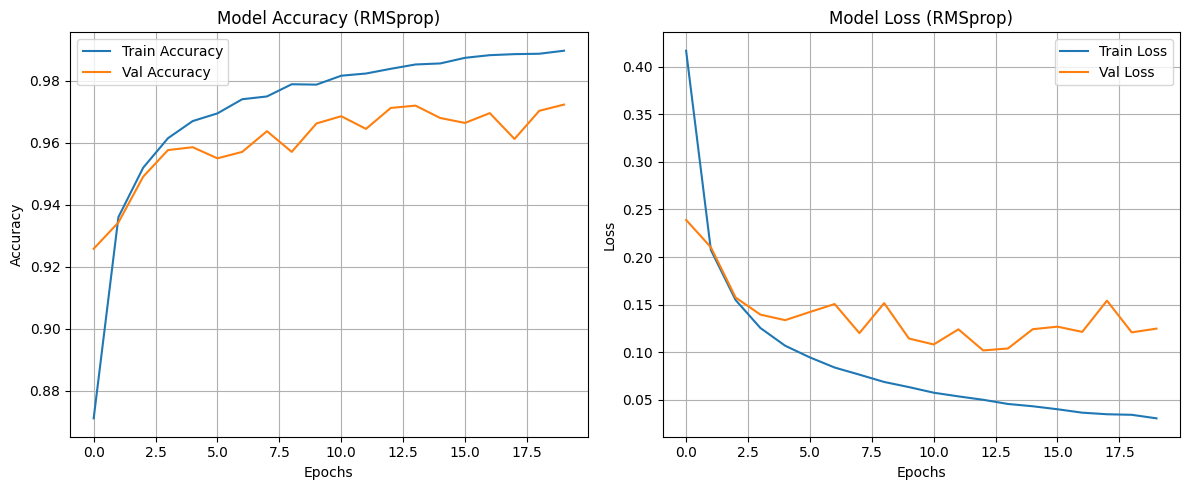


Running optimizer experiment: Adam
Epoch [1/20] | Train Loss: 0.4364, Train Acc: 0.8706 | Val Loss: 0.2691, Val Acc: 0.9201
Epoch [2/20] | Train Loss: 0.2125, Train Acc: 0.9370 | Val Loss: 0.1880, Val Acc: 0.9437
Epoch [3/20] | Train Loss: 0.1521, Train Acc: 0.9533 | Val Loss: 0.1446, Val Acc: 0.9553
Epoch [4/20] | Train Loss: 0.1246, Train Acc: 0.9610 | Val Loss: 0.1573, Val Acc: 0.9518
Epoch [5/20] | Train Loss: 0.1034, Train Acc: 0.9681 | Val Loss: 0.1450, Val Acc: 0.9545
Epoch [6/20] | Train Loss: 0.0891, Train Acc: 0.9723 | Val Loss: 0.1079, Val Acc: 0.9677
Epoch [7/20] | Train Loss: 0.0809, Train Acc: 0.9736 | Val Loss: 0.1082, Val Acc: 0.9704
Epoch [8/20] | Train Loss: 0.0699, Train Acc: 0.9774 | Val Loss: 0.1049, Val Acc: 0.9696
Epoch [9/20] | Train Loss: 0.0637, Train Acc: 0.9795 | Val Loss: 0.1106, Val Acc: 0.9672
Epoch [10/20] | Train Loss: 0.0607, Train Acc: 0.9800 | Val Loss: 0.1351, Val Acc: 0.9592
Epoch [11/20] | Train Loss: 0.0539, Train Acc: 0.9826 | Val Loss: 0.1008,

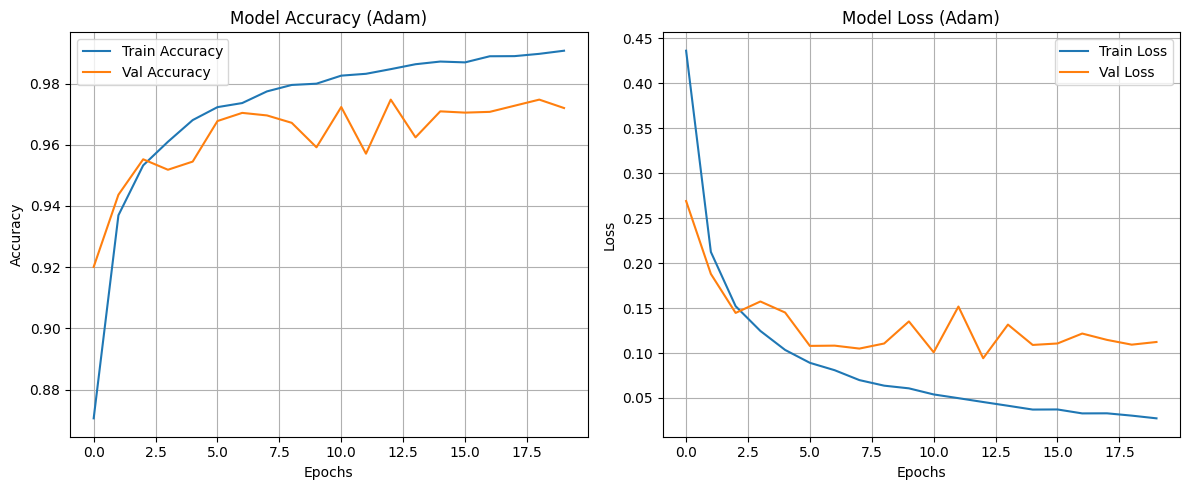


Optimizer Comparison
SGD        | Train Acc: 0.9956 | Val Acc: 0.9669 | Test Acc: 0.9704 | Loss: 0.1139 | Epochs: 20 | Time: 282.66s
RMSprop    | Train Acc: 0.9897 | Val Acc: 0.9723 | Test Acc: 0.9707 | Loss: 0.1157 | Epochs: 20 | Time: 279.61s
Adam       | Train Acc: 0.9907 | Val Acc: 0.9720 | Test Acc: 0.9746 | Loss: 0.1060 | Epochs: 20 | Time: 285.00s


In [ ]:
optimizer_results = []

optimizer_configs = [
    ("SGD", lambda params: optim.SGD(params, lr=0.01, momentum=0.9)),
    ("RMSprop", lambda params: optim.RMSprop(params, lr=0.001)),
    ("Adam", lambda params: optim.Adam(params, lr=0.001)),
]
criterion = nn.CrossEntropyLoss()
for opt_name, opt_fn in optimizer_configs:
    print(f"\nRunning optimizer experiment: {opt_name}")

    model = SimpleMLP(
        hidden1=128,
        hidden2=64,
        activation="relu",
        dropout=0.0
    ).to(device)

    optimizer = opt_fn(model.parameters())

    model, history, train_time = train_model(
        model, train_loader, val_loader, criterion, optimizer,
        num_epochs=num_epochs, ###patience=patience
    )

    test_loss, test_acc = test_model(model, test_loader, criterion)

    optimizer_results.append({
        "optimizer": opt_name,
        "final_train_acc": history["train_acc"][-1],
        "final_val_acc": history["val_acc"][-1],
        "test_acc": test_acc,
        "test_loss": test_loss,
        "epochs_run": len(history["train_acc"]),
        "train_time_sec": train_time
    })

    plot_history(history, f"({opt_name})")

# print Optimizer Comparision
print("\nOptimizer Comparison")
for r in optimizer_results:
    print(
        f"{r['optimizer']:10s} | "
        f"Train Acc: {r['final_train_acc']:.4f} | "
        f"Val Acc: {r['final_val_acc']:.4f} | "
        f"Test Acc: {r['test_acc']:.4f} | "
        f"Loss: {r['test_loss']:.4f} | "
        f"Epochs: {r['epochs_run']} | "
        f"Time: {r['train_time_sec']:.2f}s"
    )

Task_04: Observe and interpret the training and validation accuracy and loss curves.


Running Task 4 experiment: No_Regularization
Epoch [1/30] | Train Loss: 0.4214, Train Acc: 0.8710 | Val Loss: 0.2664, Val Acc: 0.9143
Epoch [2/30] | Train Loss: 0.1811, Train Acc: 0.9432 | Val Loss: 0.1470, Val Acc: 0.9539
Epoch [3/30] | Train Loss: 0.1323, Train Acc: 0.9594 | Val Loss: 0.1269, Val Acc: 0.9605
Epoch [4/30] | Train Loss: 0.1081, Train Acc: 0.9669 | Val Loss: 0.1351, Val Acc: 0.9587
Epoch [5/30] | Train Loss: 0.0900, Train Acc: 0.9718 | Val Loss: 0.1082, Val Acc: 0.9665
Epoch [6/30] | Train Loss: 0.0799, Train Acc: 0.9748 | Val Loss: 0.1151, Val Acc: 0.9648
Epoch [7/30] | Train Loss: 0.0711, Train Acc: 0.9768 | Val Loss: 0.1153, Val Acc: 0.9651
Epoch [8/30] | Train Loss: 0.0641, Train Acc: 0.9794 | Val Loss: 0.1104, Val Acc: 0.9683
Epoch [9/30] | Train Loss: 0.0577, Train Acc: 0.9812 | Val Loss: 0.1173, Val Acc: 0.9665
Epoch [10/30] | Train Loss: 0.0505, Train Acc: 0.9833 | Val Loss: 0.1268, Val Acc: 0.9646
Early stopping triggered.
Test Loss: 0.0964, Test Accuracy: 0.9

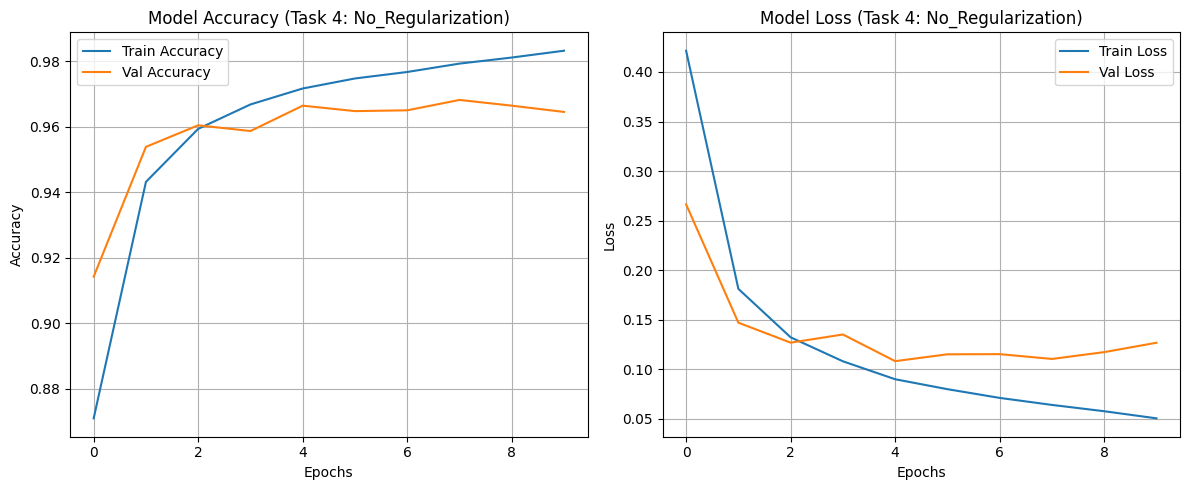


Running Task 4 experiment: Dropout_Only
Epoch [1/30] | Train Loss: 0.6033, Train Acc: 0.8069 | Val Loss: 0.2612, Val Acc: 0.9208
Epoch [2/30] | Train Loss: 0.3100, Train Acc: 0.9110 | Val Loss: 0.1848, Val Acc: 0.9451
Epoch [3/30] | Train Loss: 0.2517, Train Acc: 0.9275 | Val Loss: 0.1823, Val Acc: 0.9453
Epoch [4/30] | Train Loss: 0.2299, Train Acc: 0.9334 | Val Loss: 0.1464, Val Acc: 0.9566
Epoch [5/30] | Train Loss: 0.2043, Train Acc: 0.9419 | Val Loss: 0.1410, Val Acc: 0.9583
Epoch [6/30] | Train Loss: 0.1961, Train Acc: 0.9433 | Val Loss: 0.1500, Val Acc: 0.9567
Epoch [7/30] | Train Loss: 0.1824, Train Acc: 0.9476 | Val Loss: 0.1280, Val Acc: 0.9611
Epoch [8/30] | Train Loss: 0.1780, Train Acc: 0.9472 | Val Loss: 0.1311, Val Acc: 0.9592
Epoch [9/30] | Train Loss: 0.1665, Train Acc: 0.9520 | Val Loss: 0.1207, Val Acc: 0.9646
Epoch [10/30] | Train Loss: 0.1581, Train Acc: 0.9542 | Val Loss: 0.1109, Val Acc: 0.9680
Epoch [11/30] | Train Loss: 0.1522, Train Acc: 0.9559 | Val Loss: 0.

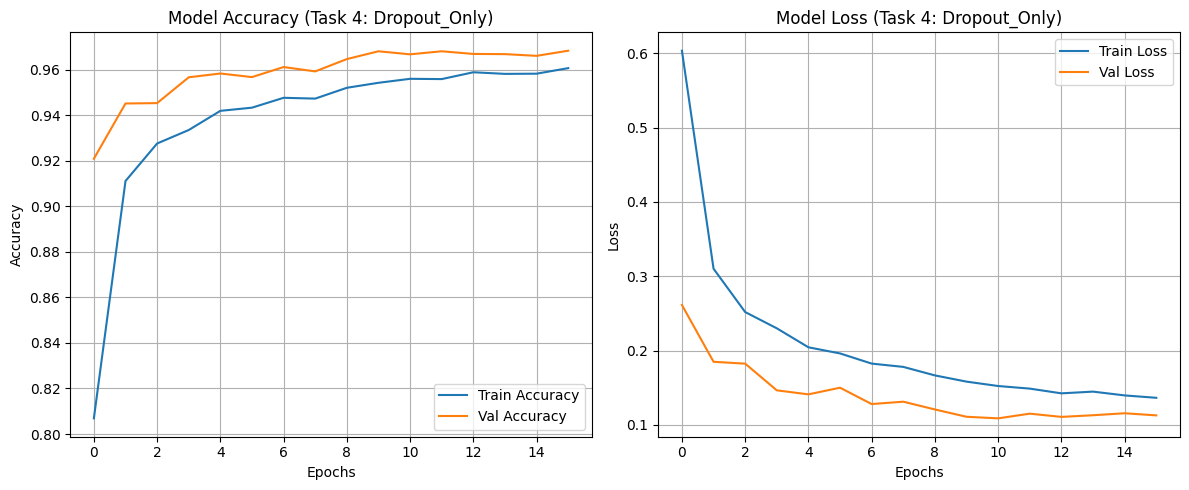


Running Task 4 experiment: L2_Only
Epoch [1/30] | Train Loss: 0.4359, Train Acc: 0.8658 | Val Loss: 0.2344, Val Acc: 0.9275
Epoch [2/30] | Train Loss: 0.1842, Train Acc: 0.9429 | Val Loss: 0.1669, Val Acc: 0.9483
Epoch [3/30] | Train Loss: 0.1362, Train Acc: 0.9580 | Val Loss: 0.1463, Val Acc: 0.9548
Epoch [4/30] | Train Loss: 0.1089, Train Acc: 0.9654 | Val Loss: 0.1442, Val Acc: 0.9547
Epoch [5/30] | Train Loss: 0.0941, Train Acc: 0.9712 | Val Loss: 0.1336, Val Acc: 0.9593
Epoch [6/30] | Train Loss: 0.0848, Train Acc: 0.9734 | Val Loss: 0.1373, Val Acc: 0.9576
Epoch [7/30] | Train Loss: 0.0752, Train Acc: 0.9760 | Val Loss: 0.1205, Val Acc: 0.9635
Epoch [8/30] | Train Loss: 0.0670, Train Acc: 0.9785 | Val Loss: 0.1358, Val Acc: 0.9595
Epoch [9/30] | Train Loss: 0.0624, Train Acc: 0.9798 | Val Loss: 0.1243, Val Acc: 0.9616
Epoch [10/30] | Train Loss: 0.0606, Train Acc: 0.9811 | Val Loss: 0.1040, Val Acc: 0.9686
Epoch [11/30] | Train Loss: 0.0530, Train Acc: 0.9830 | Val Loss: 0.1013,

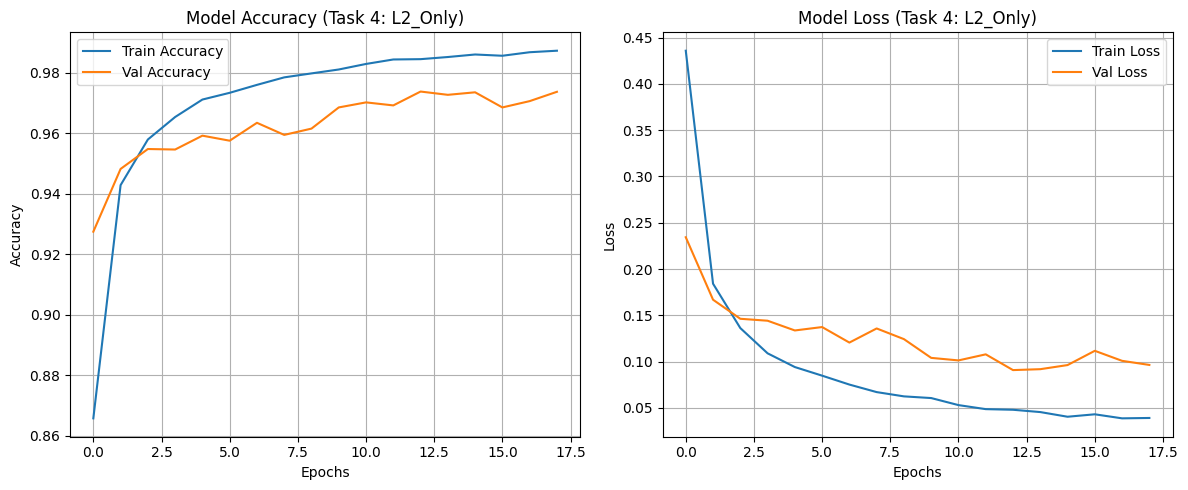


Running Task 4 experiment: Dropout_L2
Epoch [1/30] | Train Loss: 0.5895, Train Acc: 0.8158 | Val Loss: 0.2567, Val Acc: 0.9202
Epoch [2/30] | Train Loss: 0.3134, Train Acc: 0.9100 | Val Loss: 0.1876, Val Acc: 0.9422
Epoch [3/30] | Train Loss: 0.2493, Train Acc: 0.9283 | Val Loss: 0.1605, Val Acc: 0.9509
Epoch [4/30] | Train Loss: 0.2274, Train Acc: 0.9350 | Val Loss: 0.1604, Val Acc: 0.9528
Epoch [5/30] | Train Loss: 0.2082, Train Acc: 0.9394 | Val Loss: 0.1529, Val Acc: 0.9544
Epoch [6/30] | Train Loss: 0.1922, Train Acc: 0.9457 | Val Loss: 0.1366, Val Acc: 0.9592
Epoch [7/30] | Train Loss: 0.1819, Train Acc: 0.9477 | Val Loss: 0.1345, Val Acc: 0.9581
Epoch [8/30] | Train Loss: 0.1773, Train Acc: 0.9491 | Val Loss: 0.1288, Val Acc: 0.9616
Epoch [9/30] | Train Loss: 0.1684, Train Acc: 0.9512 | Val Loss: 0.1226, Val Acc: 0.9629
Epoch [10/30] | Train Loss: 0.1634, Train Acc: 0.9525 | Val Loss: 0.1214, Val Acc: 0.9644
Epoch [11/30] | Train Loss: 0.1549, Train Acc: 0.9559 | Val Loss: 0.12

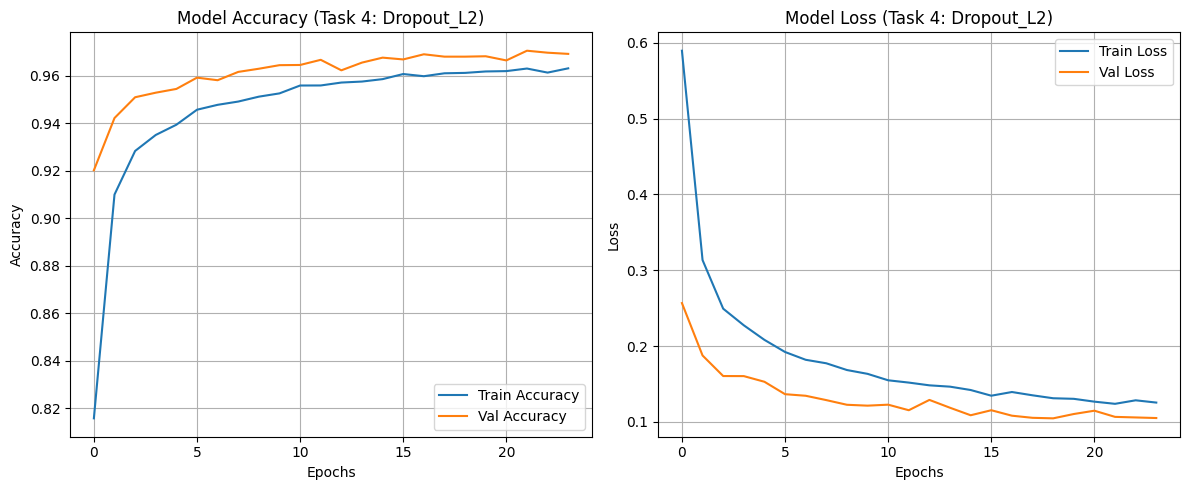


Task 4 Regularization Comparison
No_Regularization  | Dropout: 0.0 | Weight Decay: 0e+00 | Train Acc: 0.9833 | Val Acc: 0.9646 | Test Acc: 0.9708 | Test Loss: 0.0964 | Epochs: 10 | Time: 139.93s
Dropout_Only       | Dropout: 0.3 | Weight Decay: 0e+00 | Train Acc: 0.9606 | Val Acc: 0.9683 | Test Acc: 0.9702 | Test Loss: 0.0988 | Epochs: 16 | Time: 227.78s
L2_Only            | Dropout: 0.0 | Weight Decay: 1e-04 | Train Acc: 0.9873 | Val Acc: 0.9738 | Test Acc: 0.9766 | Test Loss: 0.0855 | Epochs: 18 | Time: 257.65s
Dropout_L2         | Dropout: 0.3 | Weight Decay: 1e-04 | Train Acc: 0.9631 | Val Acc: 0.9692 | Test Acc: 0.9730 | Test Loss: 0.0934 | Epochs: 24 | Time: 340.70s


In [ ]:
# Task 4: Early Stopping + Different Regularization Techniques
# Self-contained: does not modify previous cells

import time
import copy
import torch
import torch.nn as nn
import torch.optim as optim

def train_model_task4(model, train_loader, val_loader, criterion, optimizer, num_epochs=30, patience=5):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    best_val_loss = float("inf")
    best_model_wts = copy.deepcopy(model.state_dict())
    patience_counter = 0

    start_time = time.time()

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        running_acc = 0.0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            batch_size_local = labels.size(0)
            running_loss += loss.item() * batch_size_local
            running_acc += calculate_accuracy(outputs, labels) * batch_size_local
            total += batch_size_local

        train_loss = running_loss / total
        train_acc = running_acc / total

        model.eval()
        val_running_loss = 0.0
        val_running_acc = 0.0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                batch_size_local = labels.size(0)
                val_running_loss += loss.item() * batch_size_local
                val_running_acc += calculate_accuracy(outputs, labels) * batch_size_local
                val_total += batch_size_local

        val_loss = val_running_loss / val_total
        val_acc = val_running_acc / val_total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch [{epoch+1}/{num_epochs}] | "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
        )

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    model.load_state_dict(best_model_wts)
    total_time = time.time() - start_time

    return model, history, total_time


# Different regularization experiments
regularization_experiments = [
    {
        "name": "No_Regularization",
        "dropout": 0.0,
        "weight_decay": 0.0
    },
    {
        "name": "Dropout_Only",
        "dropout": 0.3,
        "weight_decay": 0.0
    },
    {
        "name": "L2_Only",
        "dropout": 0.0,
        "weight_decay": 1e-4
    },
    {
        "name": "Dropout_L2",
        "dropout": 0.3,
        "weight_decay": 1e-4
    }
]

criterion = nn.CrossEntropyLoss()
patience = 5
task4_results = []

for exp in regularization_experiments:
    print(f"\nRunning Task 4 experiment: {exp['name']}")

    model = DeepMLP(
        activation="relu",
        dropout=exp["dropout"]
    ).to(device)

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001,
        weight_decay=exp["weight_decay"]
    )

    model, history, train_time = train_model_task4(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        num_epochs=30,
        patience=patience
    )

    test_loss, test_acc = test_model(model, test_loader, criterion)

    task4_results.append({
        "name": exp["name"],
        "dropout": exp["dropout"],
        "weight_decay": exp["weight_decay"],
        "final_train_acc": history["train_acc"][-1],
        "final_val_acc": history["val_acc"][-1],
        "test_acc": test_acc,
        "test_loss": test_loss,
        "epochs_run": len(history["train_acc"]),
        "train_time_sec": train_time
    })

    plot_history(history, f"(Task 4: {exp['name']})")

print("\nTask 4 Regularization Comparison")
for r in task4_results:
    print(
        f"{r['name']:18s} | "
        f"Dropout: {r['dropout']:.1f} | "
        f"Weight Decay: {r['weight_decay']:.0e} | "
        f"Train Acc: {r['final_train_acc']:.4f} | "
        f"Val Acc: {r['final_val_acc']:.4f} | "
        f"Test Acc: {r['test_acc']:.4f} | "
        f"Test Loss: {r['test_loss']:.4f} | "
        f"Epochs: {r['epochs_run']} | "
        f"Time: {r['train_time_sec']:.2f}s"
    )